In [18]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import importlib

import pickle

import sys
sys.path.append("../../")
import methods  
importlib.reload(methods)

from decision_rules import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
plt_title = 'Opportunity Atlas Comparison: Well-specified Model, Informative X'

name = "OA_comparison_normal_mc_runs40_cost0.361_goodX"
save_title = f'../results/oa_analysis/figures/{name}.pdf'

In [24]:
load_name = f'../results/oa_analysis/{name}.pkl'

with open(load_name, 'rb') as f:
   results = pickle.load(f)

In [25]:
method_names =  {
    'naive_pval': '$p < 0.05$',
    'assure_pval': 'ASSURE $p$-val',
    'cb_pval': 'CB $p$-val',
    'naive_trunc': '$Y_i > 0$',
    'assure_trunc': 'ASSURE thresh',
    'cb_trunc': 'CB thresh',
    'naive_linear_shrink': 'Plug-in Shrinkage',
    'assure_linear_shrink': 'ASSURE Shrinkage',
    'cb_linear_shrink': 'CB Shrinkage',
    'npmle': 'NPMLE',
    'close_npmle': 'CLOSE-NPMLE',
    'close_gauss': 'CLOSE Gauss',
    'assure_close_gauss_cvx': 'Ensemble',
    'assure_close_gauss': 'ASSURE Close-Gauss',
    'assure_linear': 'ASSURE Linear',
    'cb_linear': 'CB Linear',
    'fh': 'Fay-Herriot (FH)',
    'assure_fh': 'ASSURE FH',
    'cb_fh': 'CB FH'
}

plotted_methods = [
#    'naive_pval',
#    'assure_pval',
#    'cb_pval',
#    'naive_trunc',
#    'assure_trunc',
#    'cb_trunc',
    'naive_linear_shrink',
    'assure_linear_shrink',
    'cb_linear_shrink',
    'npmle',
    'close_npmle',
    'close_gauss',
    'assure_close_gauss_cvx',
#    'assure_linear',
#    'cb_linear',
    'assure_close_gauss',
    'fh',
    'assure_fh',
    'cb_fh'
]


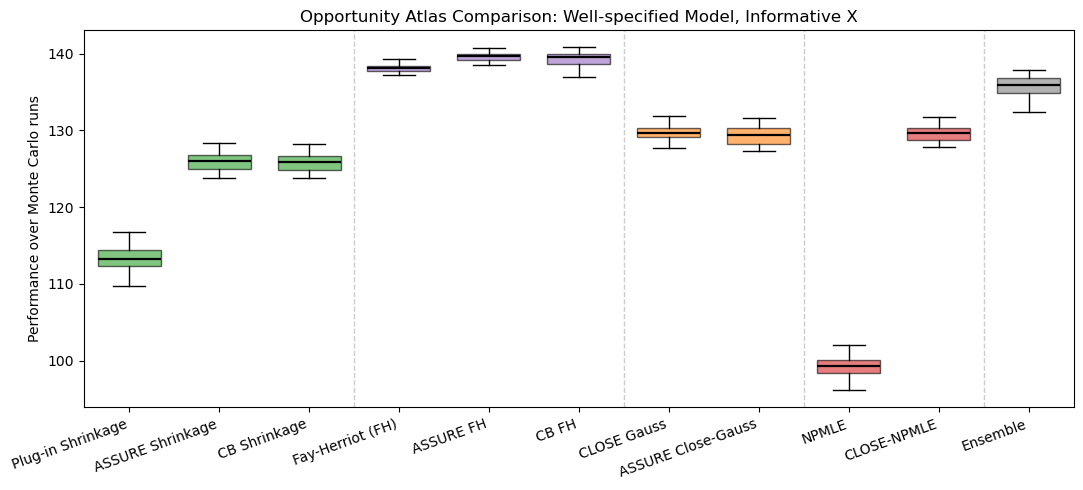

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def group_of(name: str) -> str:
    if name.endswith("pval"): return "pval"
    if name.endswith("trunc"): return "trunc"
    if name.endswith("shrink"): return "shrink"
    if name.endswith("linear"): return "linear"
    if name.endswith("fh"): return "fh"
    if name.endswith("gauss"): return "gauss"
    if name.endswith("npmle"): return "npmle"
    return "other"

group_colors = {
#    "pval": "tab:blue",
#    "trunc": "tab:orange",
    "shrink": "tab:green",
    "gauss": "tab:orange",
    "fh": "tab:purple",
    "npmle": "tab:red",
    "other": "tab:gray",
}


# order methods by group (pval, trunc, linear_shrink, other)
labels_all = plotted_methods
group_order = {"pval": 0, "trunc": 1, "shrink": 2, "linear": 3, "fh":4, "gauss":5, "npmle":6, "other": 7}
order = np.argsort([group_order[group_of(k)] for k in labels_all])

labels = [labels_all[i] for i in order]
data   = [np.asarray(results[k]) for k in labels]
colors = [group_colors[group_of(k)] for k in labels]
groups = [group_of(k) for k in labels]

# positions and plotting
x = np.arange(1, len(labels) + 1)
plt.figure(figsize=(11, 5))
bp = plt.boxplot(
    data,
    positions=x,
    widths=0.7,
    patch_artist=True,
    showfliers=False,   # show outliers
    whis=1.5           # standard Tukey whiskers
)

# color each box (and style whiskers, caps, medians, fliers)
for i in range(len(labels)):
    c = colors[i]
    plt.setp(bp['boxes'][i], facecolor=c, edgecolor='black', alpha=0.6, linewidth=1)
    plt.setp(bp['medians'][i], color='black', linewidth=1.6)
    plt.setp(bp['whiskers'][2*i],   color='black', linewidth=1)
    plt.setp(bp['whiskers'][2*i+1], color='black', linewidth=1)
    plt.setp(bp['caps'][2*i],   color='black', linewidth=1)
    plt.setp(bp['caps'][2*i+1], color='black', linewidth=1)
    # fliers (outliers)
    if len(bp['fliers']) > i:
        plt.setp(bp['fliers'][i], marker='o', markersize=3, markerfacecolor=c, markeredgecolor='black', alpha=0.5)

# x-axis labels
plt.xticks(x, [method_names[labels_all[i]] for i in order], rotation=20, ha="right")
plt.ylabel("Performance over Monte Carlo runs")
plt.title("Method Performance: Box-and-Whisker by Method (group-colored)")

# vertical separators between groups
boundaries = [i for i in range(1, len(groups)) if groups[i] != groups[i-1]]
for b in boundaries:
    plt.axvline(b + 0.5, color='0.8', linewidth=1, linestyle='--', zorder=0)

# legend from present groups
present_groups = []
for g in groups:
    if g not in present_groups:
        present_groups.append(g)
legend_handles = [Patch(facecolor=group_colors[g], edgecolor='black', label=g, alpha=0.6) for g in present_groups]
#plt.legend(handles=legend_handles, title="Group", frameon=True)

plt.tight_layout()
plt.title(plt_title)
plt.savefig(save_title, bbox_inches='tight')
plt.show()
